In [2]:
import pandas as pd
import os
import re
import shutil
from pyxnat import Interface



In [3]:

# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
csv_file = 'Label_Paper.xlsx'
download_dir = './descargas_xnat_segura'

SERVER = 'https://ceib.cipf.es/xnat2'
USER = 'jaalzate'
PASSWORD = 'jaalzate'

if not os.path.exists(download_dir):
    os.makedirs(download_dir)

# ==========================================
# FUNCIONES AUXILIARES
# ==========================================
def analizar_y_renombrar(ruta_base_scan):
    """
    Busca carpetas con nombres numéricos dentro de ruta_base_scan.
    Identifica si son NIFTI o DICOM y las renombra.
    IGNORA la carpeta llamada 'SEGMENTATION'.
    """
    # Extensiones
    NIFTI_EXT = ('.nii', '.nii.gz')
    DICOM_EXT = ('.dcm', '.ima')

    for item in os.listdir(ruta_base_scan):
        item_path = os.path.join(ruta_base_scan, item)
        
        # 1. Solo procesamos carpetas
        if not os.path.isdir(item_path):
            continue
            
        # 2. PROTECCIÓN: Si la carpeta se llama SEGMENTATION, NO LA TOCAMOS
        if item.upper() == 'SEGMENTATION':
            continue

        # 3. Si la carpeta ya se llama DICOM o NIFTI, saltamos
        if item.upper() in ['DICOM', 'NIFTI']:
            continue

        # 4. Analizamos el contenido para decidir el nuevo nombre
        nuevo_nombre = None
        archivos = os.listdir(item_path)
        
        # Buscamos evidencias
        tiene_nifti = any(f.lower().endswith(NIFTI_EXT) for f in archivos)
        tiene_dicom = any(f.lower().endswith(DICOM_EXT) for f in archivos)

        if tiene_nifti:
            nuevo_nombre = 'NIFTI'
        elif tiene_dicom:
            nuevo_nombre = 'DICOM'
        
        # 5. Renombrar
        if nuevo_nombre:
            destino = os.path.join(ruta_base_scan, nuevo_nombre)
            print(f"      [Renombrando] '{item}' -> '{nuevo_nombre}'")
            
            if os.path.exists(destino):
                print(f"      [!] La carpeta {nuevo_nombre} ya existe. Fusionando contenido...")
                for f in os.listdir(item_path):
                    shutil.move(os.path.join(item_path, f), os.path.join(destino, f))
                os.rmdir(item_path) # Borrar la carpeta vieja vacía
            else:
                os.rename(item_path, destino)


In [ ]:

# ==========================================
# 2. CONEXIÓN Y LECTURA
# ==========================================
print("Iniciando conexión y lectura de datos...")
df = pd.read_excel(csv_file)
df_filtered = df[df['Used'].astype(str).str.upper().isin(['TRUE', '1'])]
central = Interface(server=SERVER, user=USER, password=PASSWORD)
print(f"Sesiones a procesar: {len(df_filtered)}")


In [ ]:

# ==========================================
# 3. PROCESO DE DESCARGA
# ==========================================
for index, row in df_filtered.iterrows():
    project_id = row['project']
    subject_id = row['ID_XNAT_subject']
    experiment_id = row['ID_XNAT_session']
    
    print(f"\n--- Sesión: {experiment_id} ---")
    
    try:
        experiment = central.select.project(project_id).subject(subject_id).experiment(experiment_id)
        if not experiment.exists(): continue

        assessors = experiment.assessors()
        
        for assessor in assessors:
            ass_label = assessor.label()
            
            # Buscar patrón ...S11
            match = re.search(r'S(\d+)$', ass_label)
            
            if match:
                scan_id = match.group(1)
                print(f"  [+] Segmentación encontrada para Scan {scan_id}")
                
                # Ruta Base: ./descargas/sesion/scan_X
                base_scan_path = os.path.join(download_dir, experiment_id, f"scan_{scan_id}")
                if not os.path.exists(base_scan_path):
                    os.makedirs(base_scan_path)

                # -----------------------------------------------------
                # PASO A: DESCARGAR SEGMENTACIÓN (AISLADA)
                # -----------------------------------------------------
                # Creamos una carpeta específica para proteger la segmentación
                seg_path = os.path.join(base_scan_path, "SEGMENTATION")
                if not os.path.exists(seg_path):
                    os.makedirs(seg_path)

                print(f"      -> Descargando Segmentación en carpeta protegida...")
                ass_resources = assessor.out_resources().get()
                for res_name in ass_resources:
                    # Descargamos DENTRO de la carpeta SEGMENTATION
                    # Esto creará: .../scan_X/SEGMENTATION/ResourceName/archivo.dcm
                    try:
                        assessor.out_resource(res_name).get(seg_path, extract=True)
                    except:
                        pass # A veces fallan recursos vacíos

                # -----------------------------------------------------
                # PASO B: DESCARGAR SCAN (IMAGEN) EN LA RAÍZ
                # -----------------------------------------------------
                scan = experiment.scan(scan_id)
                if scan.exists():
                    resources = scan.resources().get()
                    print(f"      -> Descargando recursos del Scan: {resources}")
                    for res_name in resources:
                        # Descargamos en la raíz del scan
                        # Esto creará: .../scan_X/1014992/archivo.dcm
                        scan.resource(res_name).get(base_scan_path, extract=True)
                    
                    # -------------------------------------------------
                    # PASO C: RENOMBRAR (SOLO IMÁGENES)
                    # -------------------------------------------------
                    # Llamamos a la función que renombra lo numérico a DICOM/NIFTI
                    # pero respeta la carpeta 'SEGMENTATION'
                    analizar_y_renombrar(base_scan_path)

                else:
                    print(f"      [!] Scan {scan_id} no existe.")

    except Exception as e:
        print(f"  [ERROR] {experiment_id}: {e}")

print("\n--- Proceso Completado ---")

Vista previa máscara sin transformaciones: ../Files/data/validation/descargas_xnat_segura/XNAT03_E05949/scan_6/SEGMENTATION/1838255/SEG_20251031_165839_473_S6.dcm
  Shape raw: torch.Size([512, 512, 4])
  Únicos raw: [  0. 255.]


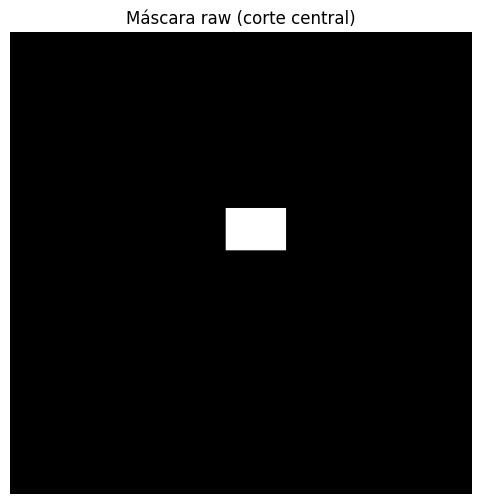

Anatomía: ../Files/data/validation/descargas_xnat_segura/XNAT03_E05949/scan_6/NIFTI/1.2.826.0.1.3680043.10.474.299538.13087470_Ax_T2_FRFSE.nii.gz
Shape Original: torch.Size([1, 512, 512, 40])
Procesando Seg 1: 1838255
Data statistics:
Type: <class 'monai.data.meta_tensor.MetaTensor'> torch.float32
Shape: torch.Size([1, 512, 512, 4])
Value range: (0.0, 1.0)
  Shape Segmentación Alineada: torch.Size([1, 512, 512, 40])
  Únicos en Seg Alineada: tensor([0., 1.])

Generando visualización 3D...
Mezclando imágenes... (Etiquetas encontradas: tensor([0., 1.]))


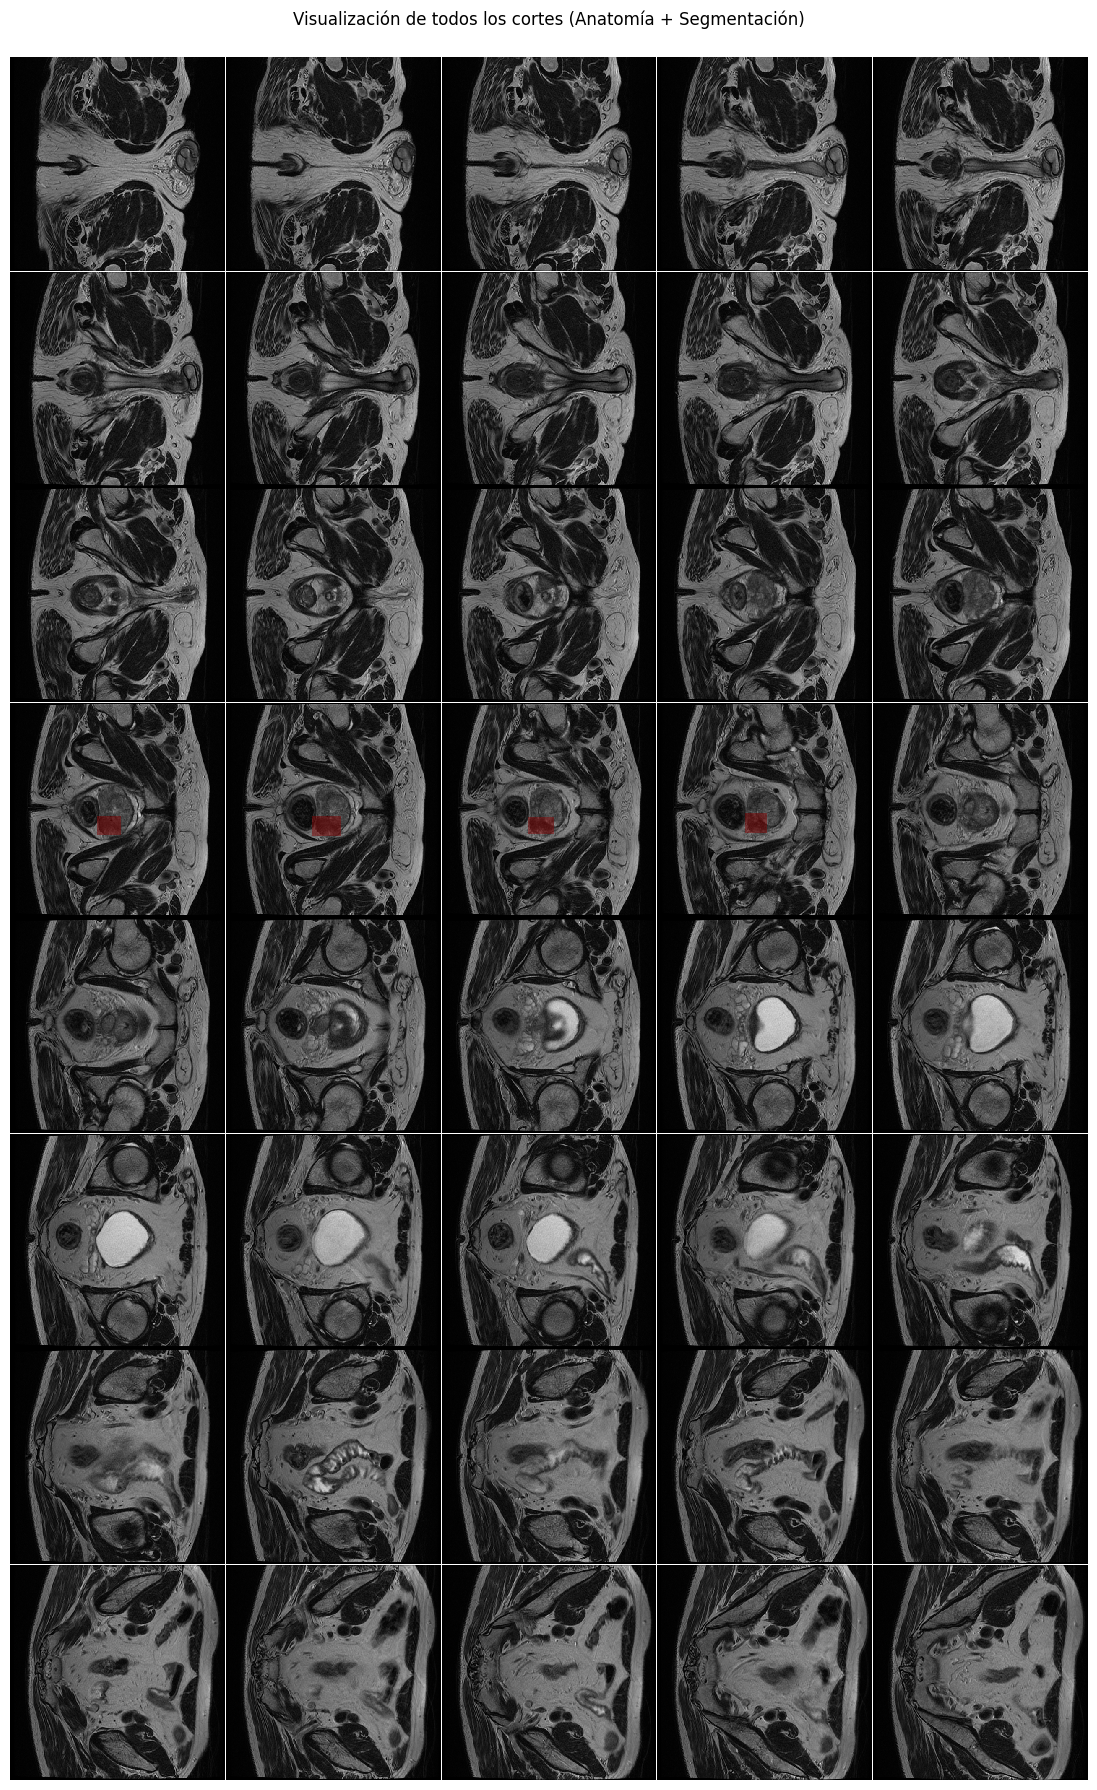

In [38]:
import os
import glob
import torch
import matplotlib.pyplot as plt
import numpy as np
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, Orientationd, Compose, ScaleIntensityd,
    ResampleToMatchd, EnsureTyped, LoadImage, AsDiscreted, DataStatsd
)
from monai.visualize import blend_images, matshow3d

# ==========================================
# 1. CONFIGURACIÓN Y RUTAS
# ==========================================
base_scan_folder = "../Files/data/validation/descargas_xnat_segura/XNAT03_E05949/scan_6"
seg_root_folder = os.path.join(base_scan_folder, "SEGMENTATION")


def encontrar_imagen_anatomica(base_path):
    """Busca robusta de la imagen anatómica."""
    if not os.path.exists(base_path):
        raise FileNotFoundError(f"No existe: {base_path}")
    
    # 1. NIFTI
    if os.path.exists(os.path.join(base_path, 'NIFTI')):
        files = glob.glob(os.path.join(base_path, 'NIFTI', "*.nii*"))
        if files: return files[0]
    
    # 2. DICOM
    if os.path.exists(os.path.join(base_path, 'DICOM')):
        return os.path.join(base_path, 'DICOM')

    # 3. Carpeta numérica
    for item in os.listdir(base_path):
        p = os.path.join(base_path, item)
        if os.path.isdir(p) and item != "SEGMENTATIONS":
            if os.listdir(p): return p
            
    raise FileNotFoundError("No se encontró imagen anatómica.")


# ==========================================
# 1.1. PREVIEW MÁSCARA RAW (SIN TRANSFORMACIONES)
# ==========================================
first_mask_path = None
if os.path.exists(seg_root_folder):
    for f in [f.path for f in os.scandir(seg_root_folder) if f.is_dir()]:
        dcm_files = glob.glob(os.path.join(f, "*.dcm")) + glob.glob(os.path.join(f, "*.ima"))
        if dcm_files:
            first_mask_path = dcm_files[0]
            break

if first_mask_path:
    print(f"Vista previa máscara sin transformaciones: {first_mask_path}")
    raw_loader = LoadImage(image_only=True, reader="ITKReader")
    raw_mask = raw_loader(first_mask_path)
    print(f"  Shape raw: {raw_mask.shape}")
    print(f"  Únicos raw: {np.unique(raw_mask)}")
    # Mostrar un corte central
    slice_idx = raw_mask.shape[-1] // 2
    plt.figure(figsize=(6, 6))
    plt.imshow(np.squeeze(raw_mask[..., slice_idx]), cmap="gray")
    plt.title("Máscara raw (corte central)")
    plt.axis("off")
    plt.show()
else:
    print("No se encontró máscara para vista previa raw.")

# ==========================================
# 2. TRANSFORMACIONES BASADAS EN DICCIONARIO
# ==========================================

# Transform para solo imagen (cargamos una vez para la anatomía)
image_transform = Compose([
    LoadImaged(keys="image"),
    EnsureChannelFirstd(keys="image"),
    Orientationd(keys="image", axcodes="RAS"),
    ScaleIntensityd(keys="image"),
    EnsureTyped(keys="image"),
])

# Transform conjunto imagen + label (re-muestrea label respecto a la imagen)
pair_transform = Compose([
    LoadImaged(keys=["image", "label"], reader=["ITKReader"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityd(keys="image"),
    EnsureTyped(keys=["image", "label"]),
    AsDiscreted(keys="label", n_classes=2,threshold=0.5),
    DataStatsd(keys="label"),
    ResampleToMatchd(keys="label", key_dst="image", mode="nearest", padding_mode="zeros")
])

# ==========================================
# 3. CARGA DE DATOS
# ==========================================
try:
    anat_path = encontrar_imagen_anatomica(base_scan_folder)
    print(f"Anatomía: {anat_path}")
    anat_sample = image_transform({"image": anat_path})
    anat_vol = anat_sample["image"]
    print(f"Shape Original: {anat_vol.shape}")
except Exception as e:
    print(f"Error: {e}")
    exit()

# Crear un volumen vacío para acumular la segmentación (única etiqueta)
total_seg_vol = torch.zeros_like(anat_vol)

found_segs = False
if os.path.exists(seg_root_folder):
    subfolders = [f.path for f in os.scandir(seg_root_folder) if f.is_dir()]
    
    for idx, folder in enumerate(subfolders):
        seg_name = os.path.basename(folder)
        dcm_files = glob.glob(os.path.join(folder, "*.dcm")) + glob.glob(os.path.join(folder, "*.ima"))
        
        if dcm_files:
            print(f"Procesando Seg {idx+1}: {seg_name}")
            try:
                sample = pair_transform({"image": anat_path, "label": dcm_files[0]})
                anat_vol = sample["image"]
                curr_seg = sample["label"]

                print(f"  Shape Segmentación Alineada: {curr_seg.shape}")
                print(f"  Únicos en Seg Alineada: {torch.unique(curr_seg)}")

                # Unimos todas las segmentaciones en una sola etiqueta binaria
                label_value = torch.tensor(1, dtype=total_seg_vol.dtype, device=total_seg_vol.device)
                total_seg_vol = torch.where(curr_seg > 0, label_value, total_seg_vol)
                
                found_segs = True
            except Exception as e:
                print(f"  [!] Fallo en {seg_name}: {e}")

# ==========================================
# 4. VISUALIZACIÓN CON MATSHOW3D
# ==========================================
print("\nGenerando visualización 3D...")

plt.figure(figsize=(18, 18))

if found_segs:
    # Fusión: Anatomía + Máscara combinada (etiqueta única)
    print(f"Mezclando imágenes... (Etiquetas encontradas: {torch.unique(total_seg_vol)})")
    blended_vol = blend_images(
        image=anat_vol,
        label=total_seg_vol,
        alpha=0.5,
        cmap="jet"
    )
    
    matshow3d(
        volume=blended_vol,
        fig=plt.gca(),
        title="Visualización de todos los cortes (Anatomía + Segmentación)",
        every_n=1,
        frames_per_row=5,
        channel_dim=0,
        frame_dim=-1
    )
else:
    print("No se encontraron segmentaciones. Mostrando solo anatomía.")
    matshow3d(
        volume=anat_vol,
        fig=plt.gca(),
        title="Anatomía (Sin Segmentación)",
        every_n=1,
        frames_per_row=6,
        cmap="gray",
        channel_dim=0
    )

plt.tight_layout()
plt.show()
